Best Match Score: 0.8847023


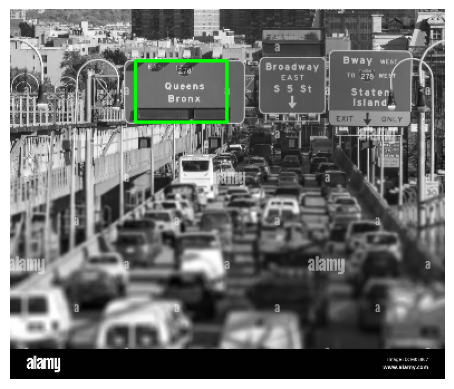

In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
img=cv2.imread("D:/23108109/F19.jpg",0)
template=cv2.imread("D:/23108109/FF4.jpg",0)
img=cv2.resize(img,None,fx=0.3,fy=0.3)
template=cv2.resize(template,None,fx=0.3,fy=0.3)
th,tw=template.shape
def fitness(x,y):
    roi=img[y:y+th,x:x+tw]
    return cv2.matchTemplate(roi,template,cv2.TM_CCORR_NORMED)[0][0]
num_particles=5
iterations=10
w=0.5
c1=1
c2=2
positions=[np.array([random.randint(0,img.shape[1]-tw),random.randint(0,img.shape[0]-th)]) for _ in range(num_particles)]
velocities=[np.zeros(2) for _ in range(num_particles)]
pBests=positions[:]
pBest_scores=[fitness(*p) for p in pBests]
gBest=pBests[np.argmax(pBest_scores)]
gBest_score=max(pBest_scores)
for _ in range(iterations):
    for i in range(num_particles):
        r1=random.random()
        r2=random.random()
        velocities[i]=(w*velocities[i]+c1*r1*(pBests[i]-positions[i])+c2*r2*(gBest-positions[i]))
        positions[i]=np.clip(positions[i]+velocities[i],[0,0],[img.shape[1]-tw,img.shape[0]-th]).astype(int)
        score=fitness(*positions[i])
        if score>pBest_scores[i]:
            pBests[i]=positions[i]
            pBest_scores[i]=score
        if score>gBest_score:
            gBest=positions[i]
            gBest_score=score
result=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
cv2.rectangle(result,tuple(gBest),(gBest[0]+tw,gBest[1]+th),(0,255,0),2)
print("Best Match Score:",gBest_score)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Iteration 1, Best Fitness: 3.43504, Best Solution: [-0.16544344 -0.78061026]
Iteration 2, Best Fitness: 0.66732, Best Solution: [-0.1136238  -0.03185143]
Iteration 3, Best Fitness: 0.30070, Best Solution: [-0.06616314  0.00486551]
Iteration 4, Best Fitness: 0.05520, Best Solution: [-0.00050353 -0.01684256]
Iteration 5, Best Fitness: 0.05520, Best Solution: [-0.00050353 -0.01684256]
Iteration 6, Best Fitness: 0.04478, Best Solution: [-0.00821457 -0.01132626]
Iteration 7, Best Fitness: 0.04478, Best Solution: [-0.00821457 -0.01132626]
Iteration 8, Best Fitness: 0.04478, Best Solution: [-0.00821457 -0.01132626]
Iteration 9, Best Fitness: 0.04472, Best Solution: [-0.00340691 -0.01355433]
Iteration 10, Best Fitness: 0.02618, Best Solution: [-0.00816974  0.00257053]
Iteration 11, Best Fitness: 0.02618, Best Solution: [-0.00816974  0.00257053]
Iteration 12, Best Fitness: 0.00988, Best Solution: [-0.00319637 -0.00111325]
Iteration 13, Best Fitness: 0.00988, Best Solution: [-0.00319637 -0.00111

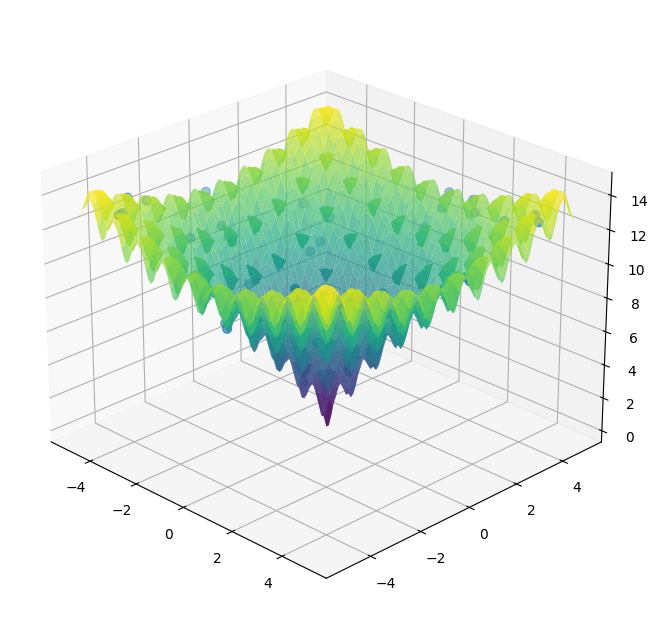

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
def ackley_fun(x):
    return (-20 * np.exp(-0.2 * np.sqrt(0.5 * (x[0]**2 + x[1]**2)))- np.exp(0.5 * (np.cos(2 * np.pi * x[0]) + np.cos(2 * np.pi * x[1])))+ np.exp(1)+ 20)
def pso2D(fitness_fun,data_range,num_particles=100,num_iterations=50,c1=0.8,c2=0.9,w=0.5):
    population = np.random.uniform(low=data_range[0],high=data_range[1],size=(num_particles, 2))
    velocities = np.zeros((num_particles, 2))
    personal_bests = np.full(num_particles, np.inf)
    personal_best_solutions = np.copy(population)
    global_best = np.inf
    best_solution = population[0]
    history = []
    for iteration in range(num_iterations):
        history.append(np.copy(population))
        for j in range(num_particles):
            score = fitness_fun(population[j])
            if score < personal_bests[j]:
                personal_bests[j] = score
                personal_best_solutions[j] = population[j]
        if np.min(personal_bests) < global_best:
            global_best = np.min(personal_bests)
            best_solution = personal_best_solutions[np.argmin(personal_bests)]
        print(f"Iteration {iteration+1}, "f"Best Fitness: {global_best:.5f}, "f"Best Solution: {best_solution}")
        for i, particle in enumerate(population):
            velocities[i] = (w * velocities[i]+ c1 * np.random.rand() * (personal_best_solutions[i] - particle)+ c2 * np.random.rand() * (best_solution - particle))
            population[i] = particle + velocities[i]
    return history
history = pso2D(ackley_fun,(-5, 5),num_particles=50,num_iterations=30)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.array([[ackley_fun([x, y]) for x in x]for y in y])
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X,Y,Z,cmap='viridis',edgecolor='none',alpha=0.7)
data = history[0]
scat = ax.scatter(data[:, 0],data[:, 1],[ackley_fun(p) for p in data],s=40)
def animate(frame):
    data = history[frame]
    scat._offsets3d = (data[:, 0],data[:, 1],[ackley_fun(p) for p in data])
    ax.set_title(f"Iteration {frame+1}")
    return scat,
ax.view_init(25, -45)
ani = animation.FuncAnimation(fig,animate,frames=len(history),interval=300,blit=False)
plt.show()

Best Match Score: 0.28113827


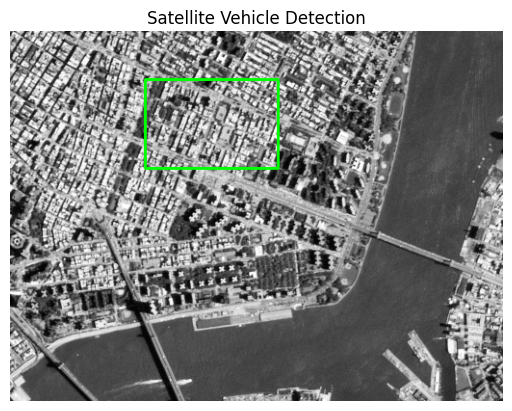

In [3]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
img=cv2.imread("D:/23108109/F7.jpg",0)
template=cv2.imread("D:/23108109/FF4.jpg",0)
img=cv2.resize(img,None,fx=0.5,fy=0.5)
template=cv2.resize(template,None,fx=0.5,fy=0.5)
th,tw=template.shape
def fitness(x,y):
    roi=img[y:y+th,x:x+tw]
    edges=cv2.Canny(roi,100,200)
    temp_edges=cv2.Canny(template,100,200)
    return cv2.matchTemplate(edges,temp_edges,cv2.TM_CCORR_NORMED)[0][0]
num_particles=10
iterations=20
w=0.5
c1=1
c2=2
positions=[np.array([random.randint(0,img.shape[1]-tw),random.randint(0,img.shape[0]-th)]) for _ in range(num_particles)]
velocities=[np.zeros(2) for _ in range(num_particles)]
pBests=positions[:]
pBest_scores=[fitness(*p) for p in pBests]
gBest=pBests[np.argmax(pBest_scores)]
gBest_score=max(pBest_scores)
for _ in range(iterations):
    for i in range(num_particles):
        r1=random.random()
        r2=random.random()
        velocities[i]=(w*velocities[i]+c1*r1*(pBests[i]-positions[i])+c2*r2*(gBest-positions[i]))
        positions[i]=np.clip(positions[i]+velocities[i],[0,0],[img.shape[1]-tw,img.shape[0]-th]).astype(int)
        score=fitness(*positions[i])
        if score>pBest_scores[i]:
            pBests[i]=positions[i]
            pBest_scores[i]=score
        if score>gBest_score:
            gBest=positions[i]
            gBest_score=score
result=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
cv2.rectangle(result,tuple(gBest),(gBest[0]+tw,gBest[1]+th),(0,255,0),2)
print("Best Match Score:",gBest_score)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title("Satellite Vehicle Detection")
plt.axis("off")
plt.show()

Best Match Score: inf


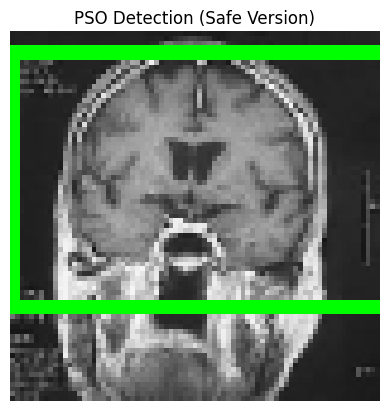

In [4]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
img_path=r"D:/23108109/F20.jpg"
temp_path=r"D:/23108109/F35.jpg"
img=cv2.imread(img_path,0)
template=cv2.imread(temp_path,0)
if img is None:
    raise Exception("Main image not found")
if template is None:
    raise Exception("Template image not found")
img=cv2.resize(img,(0,0),fx=0.5,fy=0.5)
template=cv2.resize(template,(0,0),fx=0.5,fy=0.5)
h,w=img.shape
th,tw=template.shape
if th>=h or tw>=w:
    scale=min((h-1)/th,(w-1)/tw)
    img=cv2.resize(img,(0,0),fx=scale,fy=scale)
    template=cv2.resize(template,(0,0),fx=scale,fy=scale)
    h,w=img.shape
    th,tw=template.shape
def fitness(x,y):
    x=int(x)
    y=int(y)
    if x<0 or y<0 or x+tw>w or y+th>h:
        return float('inf')
    roi=img[y:y+th,x:x+tw]
    if roi.shape!=template.shape:
        return float('inf')
    return np.sum((roi-template)**2)
num_particles=10
iterations=20
w_inertia=0.5
c1=1
c2=2
positions=[]
for _ in range(num_particles):
    positions.append(np.array([random.randint(0,max(0,w-tw)), random.randint(0,max(0,h-th))],dtype=float))
velocities=[np.zeros(2) for _ in range(num_particles)]
pBests=positions.copy()
pBest_scores=[fitness(p[0],p[1]) for p in pBests]
gBest=pBests[np.argmin(pBest_scores)]
gBest_score=min(pBest_scores)
for _ in range(iterations):
    for i in range(num_particles):
        r1=random.random()
        r2=random.random()
        velocities[i]=(w_inertia*velocities[i]+c1*r1*(pBests[i]-positions[i])+c2*r2*(gBest-positions[i]))
        positions[i]=positions[i]+velocities[i]
        positions[i][0]=np.clip(positions[i][0],0,w-tw)
        positions[i][1]=np.clip(positions[i][1],0,h-th)
        score=fitness(positions[i][0],positions[i][1])
        if score<pBest_scores[i]:
            pBests[i]=positions[i].copy()
            pBest_scores[i]=score
        if score<gBest_score:
            gBest=positions[i].copy()
            gBest_score=score
result=cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
x,y=int(gBest[0]),int(gBest[1])
cv2.rectangle(result,(x,y),(x+tw,y+th),(0,255,0),2)
print("Best Match Score:",gBest_score)
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("PSO Detection (Safe Version)")
plt.show()